# HIV Intervention Analysis

Evaluation of integrated HIV inteventions and viral suppression among children in Mazowe District

## 1. Introduction

This project evaluates the impact of integrated HIV intervention programs on viral load suppression among children living with HIV in Mazowe District. The analysis uses propensity score matching to reduce selection bias and estimate the causal effect of intervention programs on viral suppression outcomes.

## Methodology Summary

This study estimates the effect of integrated HIV intervention programs on viral load suppression using a causal inference framework.

The workflow consists of:

1. Exploratory data analysis to understand distributions and relationships  
2. Estimation of propensity scores using logistic regression  
3. Matching treated and untreated individuals using nearest neighbor matching  
4. Assessing covariate balance after matching  
5. Estimating the treatment effect on viral suppression  
6. Using logistic regression to analyze demographic predictors of viral suppression  

This approach helps reduce selection bias and provides a more reliable estimate of the intervention effect.

## 2. Data Description

The dataset contains information on children living with HIV receiving treatment in Mazowe District. Variables include demographic characteristics, treatment status, viral load suppression outcomes, and intervention-related variables.

In [1]:
import pandas as pd
data = pd.read_excel("../data/propensityscoredata.xlsx")
data.head()

,ID,HIV Status,Age,Health Facility for ART,ZW- Viral load results,viral load supression,viral load supression 1,Sex,disclosure status,disclosure status1,treatment literacy,adherence support,Treatment
0,1,Positive,9,Mazowe - Vonabor - 101744 - Clinic,314.0,Suppressed,1,Female,Partially disclosed,0,yes,yes,1
1,2,Positive,9,Mazowe - Vonabor - 101744 - Clinic,15900.0,Not Suppressed,0,Female,Partially disclosed,0,yes,yes,1
2,3,Positive,17,Mazowe - Mvurwi - 101192 - Hospital,0.0,Suppressed,1,Male,Fully disclosed,1,yes,yes,1
3,4,Positive,9,Mazowe - Concession - 100345 - District Hospital,40.0,Suppressed,1,Female,Partially disclosed,0,,yes,1
4,5,Positive,14,Mazowe - Mvurwi - 101192 - Hospital,0.0,Suppressed,1,Female,Fully disclosed,1,yes,yes,1


In [2]:
data.shape #lets us know the number of rows and columns

(2230, 13)

In [3]:
data.columns

Index(['ID', 'HIV Status', 'Age', 'Health Facility for ART',
       'ZW- Viral load results', 'viral load supression ',
       'viral load supression 1', 'Sex', 'disclosure status',
       'disclosure status1', 'treatment literacy', 'adherence support',
       'Treatment '],
      dtype='object')

In [4]:
data.info()#checking data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2230 entries, 0 to 2229
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2230 non-null   int64  
 1   HIV Status               2230 non-null   object 
 2   Age                      2230 non-null   int64  
 3   Health Facility for ART  2226 non-null   object 
 4   ZW- Viral load results   2009 non-null   float64
 5   viral load supression    2230 non-null   object 
 6   viral load supression 1  2230 non-null   int64  
 7   Sex                      2230 non-null   object 
 8   disclosure status        2219 non-null   object 
 9   disclosure status1       2230 non-null   int64  
 10  treatment literacy       2230 non-null   object 
 11  adherence support        2230 non-null   object 
 12  Treatment                2230 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 226.6+ KB


In [5]:
#checkingmissingvalues
data.isnull().sum()

ID                           0
HIV Status                   0
Age                          0
Health Facility for ART      4
ZW- Viral load results     221
viral load supression        0
viral load supression 1      0
Sex                          0
disclosure status           11
disclosure status1           0
treatment literacy           0
adherence support            0
Treatment                    0
dtype: int64

In [6]:
data.columns = data.columns.str.strip() #removing extra space from all column names

In [7]:
data['Treatment'].value_counts()

1    1333
0     897
Name: Treatment, dtype: int64

## 3. Data Cleaning

This section prepares the dataset for analysis by selecting relevant variables, handling categorical variables, and creating numeric indicators required for statistical modeling.

In [8]:
#creating a clean modeling dataset and keeping only the variables needed for the Propensity Score model
psm_data = data[['Treatment',
                'Age',
                 'Sex',
                'disclosure status1',
                'treatment literacy',
                'adherence support',
                'viral load supression 1']]

In [9]:
psm_data.columns
psm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2230 entries, 0 to 2229
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Treatment                2230 non-null   int64 
 1   Age                      2230 non-null   int64 
 2   Sex                      2230 non-null   object
 3   disclosure status1       2230 non-null   int64 
 4   treatment literacy       2230 non-null   object
 5   adherence support        2230 non-null   object
 6   viral load supression 1  2230 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 122.1+ KB


In [10]:
#converting text variables into numbers
psm_data = pd.get_dummies(psm_data, drop_first=True)

In [11]:
psm_data.head()

,Treatment,Age,disclosure status1,viral load supression 1,Sex_Male,treatment literacy_no,treatment literacy_yes,adherence support_yes
0,1,9,0,1,0,0,1,1
1,1,9,0,0,0,0,1,1
2,1,17,1,1,1,0,1,1
3,1,9,0,1,0,0,0,1
4,1,14,1,1,0,0,1,1


In [12]:
X = psm_data.drop(['Treatment','viral load supression 1'], axis=1)
y = psm_data['Treatment']
X.head()
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Treatment, dtype: int64

In [13]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X,y)

LogisticRegression(max_iter=1000)

In [14]:
psm_data['propensity_score'] = model.predict_proba(X)[:,1]
psm_data[['propensity_score']].head()

,propensity_score
0,0.997169
1,0.997169
2,0.997250
3,0.896110
4,0.997245


## 4. Exploratory Data Analysis

Exploratory analysis was conducted to understand the distribution of viral suppression outcomes and intervention status. Crosstabulations were used to examine the relationship between treatment status and viral suppression.

In [15]:
data['viral load supression 1'].value_counts()

1    1754
0     476
Name: viral load supression 1, dtype: int64

In [16]:
data['Treatment'].value_counts()

1    1333
0     897
Name: Treatment, dtype: int64

In [17]:
pd.crosstab(data['Treatment'],data['viral load supression 1'])

viral load supression 1,0,1
Treatment,,
0,201,696
1,275,1058


In [18]:
psm_data['propensity_score'].describe()

count    2230.000000
mean        0.597758
std         0.486977
min         0.004085
25%         0.004281
50%         0.997156
75%         0.997239
max         0.997290
Name: propensity_score, dtype: float64

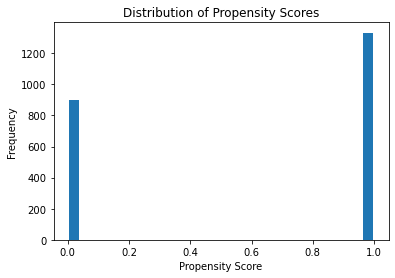

In [19]:
import matplotlib.pyplot as plt
plt.hist(psm_data['propensity_score'], bins=30)
plt.title("Distribution of Propensity Scores")
plt.xlabel("Propensity Score")
plt.ylabel("Frequency")
plt.show()


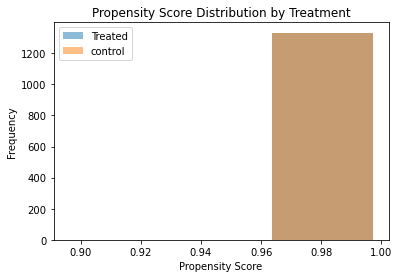

In [20]:
import matplotlib.pyplot as plt
plt.hist(psm_data[psm_data['Treatment']==1]['propensity_score'],bins=3 ,alpha=0.5,label='Treated')
plt.hist(psm_data[psm_data['Treatment']==1]['propensity_score'],bins=3 ,alpha=0.5,label='control')
plt.legend()
plt.title("Propensity Score Distribution by Treatment")
plt.xlabel("Propensity Score")
plt.ylabel("Frequency")
plt.show()


In [21]:
psm_data.groupby('Treatment')['propensity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
Treatment,,,,,,,,
0,897.0,0.004251,0.000061,0.004085,0.004211,0.004268,0.004301,0.004352
1,1333.0,0.997139,0.002770,0.896110,0.997169,0.997232,0.997250,0.997290


In [22]:
psm_trimmed = psm_data[(psm_data['propensity_score'] > 0.05) &
                       (psm_data['propensity_score'] < 0.95)]

In [23]:
pd.crosstab(data['Sex'], data['Treatment'])

Treatment,0,1
Sex,,
Female,463,676
Male,434,657


In [24]:
pd.crosstab(data['disclosure status1'], data['Treatment'])

Treatment,0,1
disclosure status1,,
0,321,431
1,576,902


In [25]:
pd.crosstab(data['adherence support'], data['Treatment'])

Treatment,0,1
adherence support,,
no,897,0
yes,0,1333


In [26]:
pd.crosstab(data['treatment literacy'], data['Treatment'])

Treatment,0,1
treatment literacy,,
,0,1
no,897,0
yes,0,1332


## 5. Propensity Score Estimation

Propensity scores were estimated using logistic regression to model the probability of receiving the intervention based on observed covariates such as age, sex, and disclosure status.

In [27]:
X =psm_data[['Age','Sex_Male','disclosure status1']]
y =psm_data['Treatment']

In [28]:
from sklearn.linear_model import LogisticRegression
logit =LogisticRegression(max_iter=1000)
logit.fit(X,y)

LogisticRegression(max_iter=1000)

In [29]:
psm_data['propensity_score'] = logit.predict_proba(X)[:,1]

In [30]:
psm_data.groupby('Treatment')['propensity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
Treatment,,,,,,,,
0,897.0,0.596954,0.017951,0.566271,0.577517,0.605832,0.613688,0.616407
1,1333.0,0.598302,0.017986,0.566271,0.577867,0.606175,0.614028,0.616746


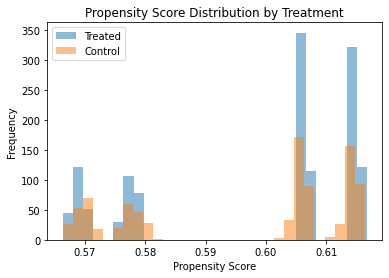

In [31]:
import matplotlib.pyplot as plt

plt.hist(psm_data[psm_data['Treatment']==1]['propensity_score'], bins=30, alpha=0.5, label='Treated')
plt.hist(psm_data[psm_data['Treatment']==0]['propensity_score'], bins=30, alpha=0.5, label='Control')

plt.legend()
plt.title("Propensity Score Distribution by Treatment")
plt.xlabel("Propensity Score")
plt.ylabel("Frequency")
plt.show()

## 6. Matching Procedure

Nearest neighbor matching was used to match treated individuals with similar untreated individuals based on their propensity scores. This approach reduces selection bias when estimating treatment effects.

In [32]:
treated = psm_data[psm_data['Treatment'] ==1]
control = psm_data[psm_data['Treatment'] ==0]

In [33]:
from sklearn.neighbors import NearestNeighbors

In [34]:
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])
distances,indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()]
matched_data = pd.concat([treated.reset_index(drop =True),
                         matched_control.reset_index(drop = True)])

In [35]:
matched_data.shape


(2666, 9)

In [36]:
matched_data['Treatment'].value_counts()

1    1333
0    1333
Name: Treatment, dtype: int64

## 7. Balance Diagnostics

After matching, covariate balance was assessed by comparing the distribution of variables between treated and control groups. Similar means across groups indicate successful matching.

In [37]:
matched_data.groupby('Treatment')[['Age','disclosure status1',]].mean()

,Age,disclosure status1
Treatment,,
0,12.693923,0.676669
1,12.696924,0.676669


In [38]:
pd.crosstab(matched_data['Treatment'],matched_data['Sex_Male'], normalize ='index')

Sex_Male,0,1
Treatment,,
0,0.507127,0.492873
1,0.507127,0.492873


In [39]:
matched_data.groupby('Treatment')['propensity_score'].describe()

,count,mean,std,min,25%,50%,75%,max
Treatment,,,,,,,,
0,1333.0,0.598301,0.017986,0.566271,0.577867,0.606175,0.614028,0.616407
1,1333.0,0.598302,0.017986,0.566271,0.577867,0.606175,0.614028,0.616746


In [40]:
matched_data.groupby('Treatment')['viral load supression 1'].mean()

Treatment
0    0.684171
1    0.793698
Name: viral load supression 1, dtype: float64

## 8. Treatment Effect Estimation

The treatment effect was estimated by comparing viral suppression rates between matched treated and control groups. A t-test was conducted to determine whether the difference in outcomes was statistically significant.

In [41]:
treated_rate = matched_data[matched_data['Treatment'] == 1]['viral load supression 1'].mean()
control_rate = matched_data[matched_data['Treatment'] == 0]['viral load supression 1'].mean()
treatment_effect = treated_rate - control_rate
treatment_effect

0.1095273818454614

In [42]:
from scipy.stats import ttest_ind

treated = matched_data[matched_data['Treatment'] == 1]['viral load supression 1']
control = matched_data[matched_data['Treatment'] == 0]['viral load supression 1']

ttest_ind(treated, control)

Ttest_indResult(statistic=6.486114493885618, pvalue=1.046208842544045e-10)

## 9. Distribution of HIV Interventions Across Health Facilities

A bar chart was used to visualize how integrated HIV interventions are distributed across health facilities in Mazowe District.

In [43]:
pd.crosstab(data['Health Facility for ART'], data['Treatment'])

Treatment,0,1
Health Facility for ART,,
Mazowe - Ardura - 100025 - Rural Health Centre,23,29
Mazowe - Bare - 100046 - Clinic,44,60
Mazowe - Belgone Clinic - 100054 - Clinic,25,42
Mazowe - Chinehasha - 100224 - Clinic,19,38
Mazowe - Christon Bank - 100332 - Clinic,8,13
Mazowe - Concession - 100345 - District Hospital,86,132
Mazowe - Cranham - 100351 - Clinic,17,22
Mazowe - Dambo - 100361 - Clinic,38,57
Mazowe - Davaar - 100369 - Clinic,12,19


<function matplotlib.pyplot.show(*args, **kw)>

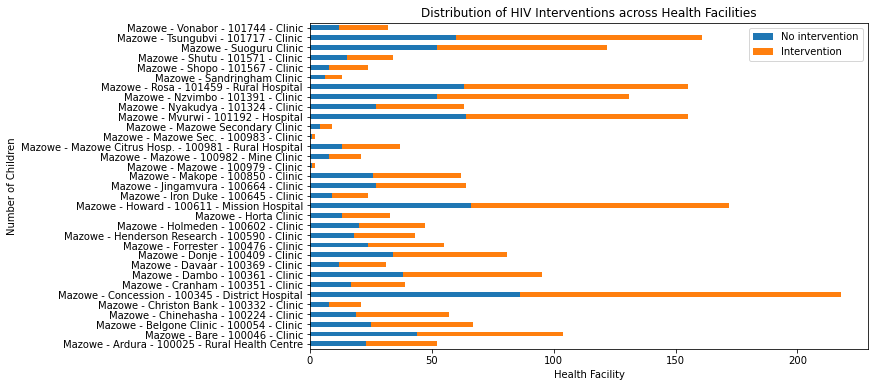

In [44]:
import matplotlib.pyplot as plt
facility_table = pd.crosstab(data['Health Facility for ART'], data['Treatment'])
facility_table.plot(kind='barh', stacked =True, figsize = (10,6))
plt.title("Distribution of HIV Interventions across Health Facilities")
plt.xlabel("Health Facility")
plt.ylabel("Number of Children")
plt.legend(["No intervention","Intervention"])
#plt.xticks(rotation=90)
plt.show




## 10. Logistic Regression Analysis

Logistic regression was used to examine the relationship between demographic characteristics and viral load suppression. Variables included age, sex, and disclosure status.

In [45]:
import statsmodels.api as sm
X = data[['Age','Sex','disclosure status1']]
X = pd.get_dummies(X, drop_first = True)
y = data['viral load supression 1']
model = sm.Logit(y, sm.add_constant(X)).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.514835
         Iterations 5
                              Logit Regression Results                             
Dep. Variable:     viral load supression 1   No. Observations:                 2230
Model:                               Logit   Df Residuals:                     2226
Method:                                MLE   Df Model:                            3
Date:                     Tue, 17 Mar 2026   Pseudo R-squ.:                0.007060
Time:                             08:33:56   Log-Likelihood:                -1148.1
converged:                            True   LL-Null:                       -1156.2
Covariance Type:                 nonrobust   LLR p-value:                 0.0009718
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.9284      0.185      5.019 

## 11. Conclusion

The analysis shows that integrated HIV intervention programs are associated with higher viral load suppression among children living with HIV in Mazowe District. After adjusting for selection bias using propensity score matching, the estimated treatment effect suggests that intervention programs increase viral suppression rates. Logistic regression results further indicate that age and disclosure status are significant predictors of viral suppression outcomes.These findings highlight the importance of applying causal inference methods such as propensity score matching when evaluating intervention programs using observational data.